# Notebook 04 - Escalamiento y Análisis de Componentes Principales (PCA)

## Paso 1. Introducción

Luego de realizar la inspección, limpieza, transformación y análisis exploratorio del conjunto de datos, el siguiente paso consiste en preparar las variables para técnicas de reducción de dimensionalidad.

En este notebook se aplicarán dos procedimientos fundamentales:

- Escalamiento de las variables numéricas.
- Análisis de Componentes Principales (Principal Component Analysis, PCA).

El escalamiento resulta necesario debido a que las variables del conjunto de datos presentan diferentes unidades y magnitudes. Sin esta etapa, las variables con mayor rango dominarían el análisis.

Posteriormente, se aplicará PCA con el objetivo de estudiar la estructura interna del dataset, identificar relaciones entre variables y evaluar la posibilidad de reducir la dimensionalidad conservando la mayor cantidad posible de información.

Las principales etapas desarrolladas serán:

- Carga del dataset procesado.
- Selección de variables numéricas.
- Escalamiento mediante StandardScaler.
- Aplicación de PCA.
- Análisis de la varianza explicada.
- Interpretación de los resultados obtenidos.

## Paso 2. Carga del conjunto de datos

En esta sección se carga el conjunto de datos previamente procesado durante el Notebook 02 y utilizado en el Análisis Exploratorio de Datos (Notebook 03).

Se utilizará el archivo `dataset_final.csv`, que contiene los datos limpios y listos para las etapas de modelado y reducción de dimensionalidad.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Cargar dataset procesado
df = pd.read_csv("/content/drive/MyDrive/PI_Mineria_Datos_1/data/processed/dataset_final.csv")

# Visualizar dimensiones
print("Dimensiones del dataset:", df.shape)

# Primeras filas
df.head()

Dimensiones del dataset: (8160, 8)


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crime,2025-03-04,99
1,10001,37,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


## Paso 3. Selección de variables numéricas

El algoritmo PCA requiere trabajar exclusivamente con variables numéricas, ya que calcula combinaciones lineales entre ellas a partir de su matriz de covarianzas (o correlaciones, cuando los datos son escalados).

Por este motivo, se seleccionan únicamente las columnas de tipo numérico presentes en el conjunto de datos. Esta selección constituye la base sobre la cual se realizará el escalamiento y posteriormente el Análisis de Componentes Principales.

Asimismo, se verifica la cantidad de variables que participarán del análisis y se listan sus nombres para asegurar que la selección sea consistente con la estructura del dataset.

In [3]:
# Seleccionar únicamente variables numéricas
df_numeric = df.select_dtypes(include=["number"])

# Cantidad de variables
print(f"Cantidad de variables numéricas: {df_numeric.shape[1]}")

# Nombre de las variables
print(df_numeric.columns.tolist())

# Vista previa
df_numeric.head()

Cantidad de variables numéricas: 4
['user_id', 'age', 'monthly_watch_time_mins', 'customer_support_tickets']


,user_id,age,monthly_watch_time_mins,customer_support_tickets
0,10000,39,805.8,99
1,10001,37,1173.4,2
2,10002,28,401.0,0
3,10003,43,62.4,0
4,10004,51,477.8,1


### Interpretación

Se identificaron inicialmente cuatro variables numéricas en el conjunto de datos:

- `user_id`
- `age`
- `monthly_watch_time_mins`
- `customer_support_tickets`

Sin embargo, `user_id` corresponde a un identificador único para cada registro y no representa una característica descriptiva del usuario. Este tipo de variable no aporta información útil sobre la estructura de los datos y su inclusión podría distorsionar el análisis realizado mediante PCA.

Por este motivo, para las etapas de escalamiento y reducción de dimensionalidad se trabajará únicamente con las variables numéricas que representan atributos reales de los usuarios.

In [4]:
# Eliminar la variable identificadora
df_numeric = df_numeric.drop(columns=["user_id"])

print(f"Cantidad de variables para PCA: {df_numeric.shape[1]}")
print(df_numeric.columns.tolist())

df_numeric.head()

Cantidad de variables para PCA: 3
['age', 'monthly_watch_time_mins', 'customer_support_tickets']


,age,monthly_watch_time_mins,customer_support_tickets
0,39,805.8,99
1,37,1173.4,2
2,28,401.0,0
3,43,62.4,0
4,51,477.8,1


## Paso 4. Escalamiento de las variables

Antes de aplicar el Análisis de Componentes Principales (PCA), es necesario estandarizar las variables numéricas.

Las variables del conjunto de datos presentan diferentes escalas de medición. Si se aplicara PCA directamente, aquellas con mayor varianza dominarían el análisis, generando componentes principales sesgadas hacia dichas variables.

Para evitar este problema, se utiliza `StandardScaler`, que transforma cada variable para que tenga media igual a cero y desviación estándar igual a uno.

Esta estandarización garantiza que todas las variables contribuyan en igualdad de condiciones al cálculo de las componentes principales.

In [5]:
from sklearn.preprocessing import StandardScaler

# Crear el escalador
scaler = StandardScaler()

# Escalar las variables
X_scaled = scaler.fit_transform(df_numeric)

# Convertir nuevamente a DataFrame para facilitar la interpretación
df_scaled = pd.DataFrame(
    X_scaled,
    columns=df_numeric.columns
)

df_scaled.head()

,age,monthly_watch_time_mins,customer_support_tickets
0,0.337908,0.023315,8.575672
1,0.200076,0.779741,0.017559
2,-0.420168,-0.809658,-0.158897
3,0.613572,-1.506409,-0.158897
4,1.164900,-0.651624,-0.070669


### Interpretación

Los resultados muestran que las variables fueron correctamente estandarizadas mediante `StandardScaler`.

Después del escalamiento, cada variable posee una media cercana a cero y una desviación estándar igual a uno. Por esta razón, los valores ya no representan las unidades originales (años, minutos o cantidad de tickets), sino puntuaciones estandarizadas (*z-scores*).

Esta transformación garantiza que ninguna variable tenga mayor influencia sobre el Análisis de Componentes Principales únicamente por presentar una escala de medición superior.

Con los datos estandarizados, el conjunto se encuentra preparado para aplicar PCA de manera adecuada.

## Paso 5. Aplicación del Análisis de Componentes Principales (PCA)

En esta etapa se aplica el algoritmo PCA sobre las variables previamente estandarizadas.

Inicialmente se calculan todas las componentes principales posibles. Esto permitirá analizar la proporción de varianza explicada por cada componente y determinar posteriormente cuántas de ellas resultan suficientes para representar adecuadamente la información contenida en el conjunto de datos.

La reducción de dimensionalidad no se realizará de manera inmediata, sino que estará fundamentada en el análisis de la varianza explicada.

In [6]:
from sklearn.decomposition import PCA

# Crear el modelo PCA conservando todas las componentes
pca = PCA()

# Ajustar el modelo a los datos escalados
pca.fit(X_scaled)

PCA()

## Paso 6. Análisis de la varianza explicada

Una vez ajustado el modelo PCA, se analiza la proporción de varianza explicada por cada componente principal.

La varianza explicada representa la cantidad de información del conjunto de datos original que es capturada por cada componente.

Asimismo, se calcula la varianza acumulada, la cual permite determinar cuántas componentes son necesarias para conservar la mayor parte de la información disponible y fundamentar la decisión sobre una eventual reducción de dimensionalidad.

In [7]:
# Crear una tabla con la varianza explicada
varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Varianza explicada": pca.explained_variance_ratio_,
    "Varianza acumulada": pca.explained_variance_ratio_.cumsum()
})

# Mostrar resultados
varianza

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.336592,0.336592
1,PC2,0.333247,0.669839
2,PC3,0.330161,1.000000


### Interpretación

La tabla de varianza explicada muestra que las tres componentes principales aportan una proporción muy similar de la variabilidad total del conjunto de datos.

En particular:

- La primera componente principal (PC1) explica aproximadamente el **33,66 %** de la varianza.
- La segunda componente principal (PC2) explica alrededor del **33,32 %**.
- La tercera componente principal (PC3) aporta el **33,02 %** restante.

La varianza acumulada indica que las dos primeras componentes conservan aproximadamente el **66,98 %** de la información, mientras que únicamente al considerar las tres componentes se alcanza el **100 %** de la varianza.

Estos resultados sugieren que la información del conjunto de datos se encuentra distribuida de forma relativamente equilibrada entre las tres variables analizadas. En consecuencia, una reducción de dimensionalidad implicaría una pérdida considerable de información, por lo que no resulta conveniente eliminar componentes únicamente con el objetivo de simplificar el conjunto de datos.

## Paso 7. Visualización de la varianza explicada

Con el propósito de facilitar la interpretación de los resultados obtenidos mediante PCA, se representa gráficamente la proporción de varianza explicada por cada componente principal junto con la varianza acumulada.

Esta visualización permite identificar de forma clara la contribución individual de cada componente y evaluar si existe una reducción significativa de la dimensionalidad sin pérdida considerable de información.

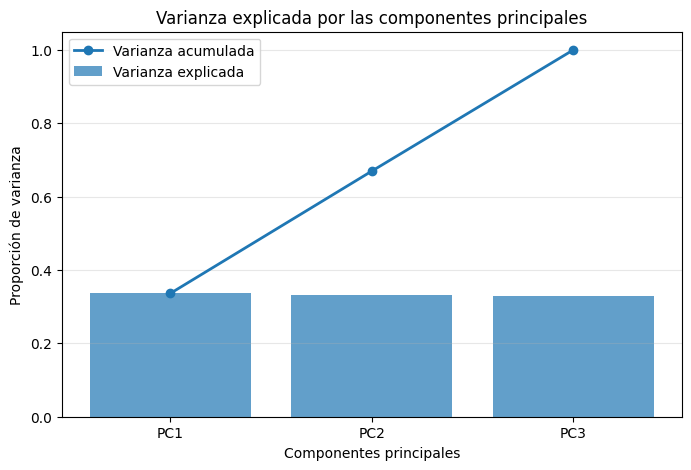

In [8]:
import matplotlib.pyplot as plt

# Crear la figura
plt.figure(figsize=(8, 5))

# Barras: varianza explicada
plt.bar(
    varianza["Componente"],
    varianza["Varianza explicada"],
    alpha=0.7,
    label="Varianza explicada"
)

# Línea: varianza acumulada
plt.plot(
    varianza["Componente"],
    varianza["Varianza acumulada"],
    marker="o",
    linewidth=2,
    label="Varianza acumulada"
)

plt.title("Varianza explicada por las componentes principales")
plt.xlabel("Componentes principales")
plt.ylabel("Proporción de varianza")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.show()

## Interpretación

El gráfico confirma visualmente lo que ya habíamos observado en la tabla: ninguna componente principal domina claramente sobre las demás. Esto fortalece la conclusión de que el PCA, en este caso, no logra una reducción de dimensionalidad significativa.

## Paso 8. Análisis de las cargas de las componentes principales

Además de conocer la proporción de varianza explicada por cada componente principal, resulta importante analizar la contribución de las variables originales en la construcción de dichas componentes.

Las cargas (*loadings*) representan los coeficientes de cada variable dentro de cada componente principal. Valores absolutos elevados indican una mayor influencia de la variable en la componente correspondiente.

El análisis de estas cargas facilita la interpretación de las componentes principales y permite comprender qué características del conjunto de datos están siendo sintetizadas por cada una de ellas.

In [9]:
# Crear una tabla con las cargas de cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df_numeric.columns
)

loadings

,PC1,PC2,PC3
age,0.160819,0.986977,-0.003583
monthly_watch_time_mins,0.698101,-0.111181,0.707314
customer_support_tickets,-0.697705,0.116251,0.706890


### Interpretación

El análisis de las cargas permite identificar qué variables tienen mayor influencia en la construcción de cada componente principal.

- **PC1** presenta una fuerte contribución positiva de `monthly_watch_time_mins` (0,698) y una fuerte contribución negativa de `customer_support_tickets` (-0,698), mientras que la variable `age` tiene una participación reducida. Esto sugiere que la primera componente representa principalmente el contraste entre el tiempo de visualización mensual y la cantidad de tickets de soporte.

- **PC2** está dominada casi exclusivamente por la variable `age` (0,987), mientras que las otras variables presentan contribuciones muy pequeñas. Por lo tanto, esta componente puede interpretarse como una dimensión asociada principalmente a la edad de los usuarios.

- **PC3** muestra contribuciones positivas similares de `monthly_watch_time_mins` (0,707) y `customer_support_tickets` (0,707), mientras que `age` prácticamente no influye. Esta componente refleja una dimensión en la que ambas variables evolucionan conjuntamente.

En conjunto, las cargas indican que las tres variables aportan información diferenciada al conjunto de datos, lo cual coincide con el análisis de la varianza explicada. Ninguna componente concentra una proporción significativamente mayor de información que las restantes, evidenciando que las variables describen aspectos distintos del comportamiento de los usuarios.

## Paso 9. Proyección de los datos sobre las componentes principales

Una vez analizadas las componentes principales, se proyectan las observaciones originales sobre el nuevo espacio definido por el modelo PCA.

Como resultado se obtiene un nuevo conjunto de datos cuyas variables corresponden a las componentes principales calculadas previamente. Esta representación puede utilizarse posteriormente en tareas de visualización, análisis exploratorio o como entrada para algoritmos de aprendizaje automático.

In [10]:
# Transformar los datos al espacio de componentes principales
X_pca = pca.transform(X_scaled)

# Crear un DataFrame con las componentes
df_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Visualizar las primeras filas
df_pca.head()

,PC1,PC2,PC3
0,-5.912669,1.327847,6.077338
1,0.564263,0.112819,0.563217
2,-0.521931,-0.343149,-0.683500
3,-0.842089,0.754594,-1.180026
4,-0.218255,1.213963,-0.515032


### Interpretación

El conjunto de datos fue proyectado correctamente sobre el nuevo espacio definido por las componentes principales.

Cada fila representa una observación original, pero expresada ahora mediante las coordenadas correspondientes a las componentes principales (PC1, PC2 y PC3), las cuales constituyen combinaciones lineales de las variables originales.

Esta nueva representación puede utilizarse como entrada para técnicas de aprendizaje automático o para realizar análisis adicionales. Sin embargo, dado que las tres componentes resultaron necesarias para conservar la totalidad de la información y las dos primeras explican únicamente el 66,98 % de la varianza, en este caso no se obtiene una reducción significativa de la dimensionalidad.

# 10. Conclusiones

En este notebook se preparó el conjunto de datos para técnicas de reducción de dimensionalidad mediante la estandarización de las variables numéricas y la aplicación del Análisis de Componentes Principales (PCA).

En primer lugar, se seleccionaron las variables numéricas relevantes para el análisis, excluyendo la columna `user_id`, ya que corresponde a un identificador y no aporta información descriptiva sobre las observaciones.

Posteriormente, las variables fueron estandarizadas utilizando `StandardScaler`, garantizando que todas contribuyeran en igualdad de condiciones al cálculo de las componentes principales, independientemente de sus escalas de medición.

El análisis de la varianza explicada mostró que las tres componentes principales aportan una proporción muy similar de información (aproximadamente un 33 % cada una). Como consecuencia, las dos primeras componentes únicamente conservan cerca del 67 % de la varianza total, mientras que es necesario considerar las tres componentes para representar completamente el conjunto de datos.

El estudio de las cargas de las componentes permitió identificar que:

- La primera componente está asociada principalmente al contraste entre el tiempo de visualización mensual y la cantidad de tickets de soporte.
- La segunda componente representa fundamentalmente la variable edad.
- La tercera componente refleja una contribución conjunta del tiempo de visualización mensual y los tickets de soporte.

En consecuencia, el análisis evidencia que las variables originales contienen información complementaria y relativamente independiente entre sí. Por este motivo, el PCA no permite una reducción significativa de la dimensionalidad sin pérdida importante de información.

En términos de minería de datos, este resultado constituye una conclusión válida y fundamentada, ya que demuestra que la estructura del conjunto de datos no presenta una redundancia suficiente como para justificar una reducción del número de variables mediante PCA.